In [2]:
import joblib             as jlb
import matplotlib.pyplot  as plt
import pandas             as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # tắt những cảnh báo

from collections           import Counter
from sklearn.decomposition import PCA
from sklearn.cluster       import DBSCAN
from data_processing import D

Tiền xử lý dữ liệu

In [3]:
features=['Age','Income','Education'
                ,'Family_Size','Total_Spend'
                ,'Wines','Food','Gold'
                ,'Wines_ratio','Food_ratio','Gold_ratio'
                ,'NumWebPurchases'
                ,'NumDealsPurchases','NumCatalogPurchases'
                ,'NumStorePurchases','NumWebVisitsMonth']
data=D[features].copy()
print(data.shape)
print(data.head(1))

(2229, 16)
        Age    Income  Education  Family_Size  Total_Spend     Wines  \
0  1.015715  0.316484  -0.893147    -1.759459     1.204332  0.985094   

       Food      Gold  Wines_ratio  Food_ratio  Gold_ratio  NumWebPurchases  \
0  1.420852  1.060908    -0.212241    0.713606   -0.618688         1.405471   

   NumDealsPurchases  NumCatalogPurchases  NumStorePurchases  \
0           0.358938             2.633984           -0.55916   

   NumWebVisitsMonth  
0            0.68992  


In [4]:
##------------------------------------------------------------------------------
## Xây dựng mô hình DBSCAN
##------------------------------------------------------------------------------
## eps        : bán kính lân cận (neighborhood radius)
## min_samples: số điểm tối thiểu trong lân cận để tạo thành core point
##
## Nhãn cluster = -1 → điểm NHIỄU (noise/outlier), không thuộc cụm nào
##------------------------------------------------------------------------------
model = DBSCAN(eps=0.3, min_samples=10)
model.fit(data)  # xây dựng mô hình

,eps,0.3
,min_samples,10
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [5]:
## Lưu trữ mô hình để khai thác về sau
jlb.dump(model,'../customer_clustering/Output/clarans.mdl')

['../customer_clustering/Output/clarans.mdl']

In [6]:
## Khai thác mô hình đã được xây dựng
model = jlb.load('../customer_clustering/Output/clarans.mdl')

In [8]:
## Kết quả gom cụm khách hàng
data['cluster'] = model.labels_
n_clusters = len(set(model.labels_)) - (1 if -1 in model.labels_ else 0)
n_noise    = list(model.labels_).count(-1)

print(f'\nSố clusters tìm được  : {n_clusters}')
print(f'Số điểm nhiễu (noise): {n_noise}')
print('\nKích thước các clusters (bao gồm noise = -1):', Counter(model.labels_))


Số clusters tìm được  : 0
Số điểm nhiễu (noise): 2229

Kích thước các clusters (bao gồm noise = -1): Counter({np.int64(-1): 2229})


In [23]:
for eps in [0.2, 0.3, 0.5, 0.8, 1.0,1.2,1.5,1.7,1.9,2.1,2.2]:
    m          = DBSCAN(eps = eps, min_samples = 2).fit(data)
    n_clusters = len(set(m.labels_)) - (1 if -1 in m.labels_ else 0)
    n_noise    = list(m.labels_).count(-1)
    print(f'eps={eps} → clusters: {n_clusters}, noise: {n_noise}')

eps=0.2 → clusters: 195, noise: 1829
eps=0.3 → clusters: 195, noise: 1828
eps=0.5 → clusters: 197, noise: 1824
eps=0.8 → clusters: 220, noise: 1772
eps=1.0 → clusters: 257, noise: 1623
eps=1.2 → clusters: 296, noise: 1340
eps=1.5 → clusters: 206, noise: 742
eps=1.7 → clusters: 103, noise: 429
eps=1.9 → clusters: 57, noise: 234
eps=2.1 → clusters: 27, noise: 114
eps=2.2 → clusters: 17, noise: 82


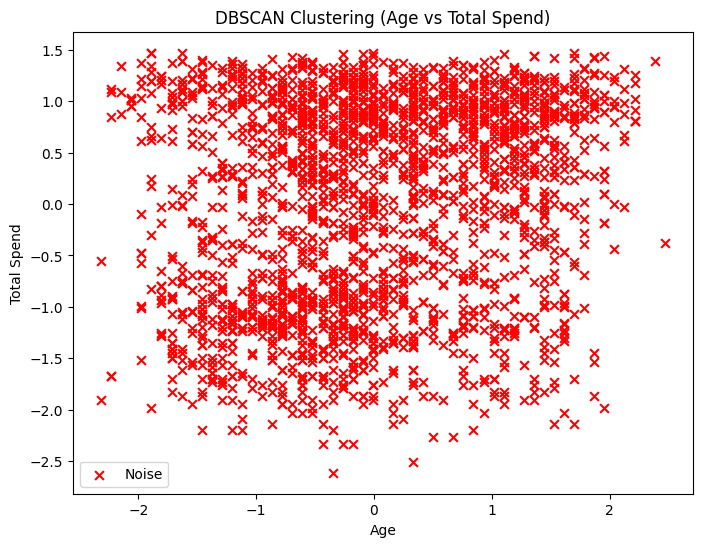

In [13]:
noise    = data[data.cluster == -1]
clusters = data[data.cluster != -1]

plt.figure(figsize=(8, 6))
plt.scatter(clusters['Age'], clusters['Total_Spend'], 
            c=clusters['cluster'])

plt.scatter(noise['Age'], noise['Total_Spend'], 
            c='red', marker='x', s=40, label='Noise')

plt.xlabel('Age')
plt.ylabel('Total Spend')
plt.title('DBSCAN Clustering (Age vs Total Spend)')
plt.legend()
plt.show()